---
## 1. Environment Setup

In [13]:
# !pip install wordcloud lime scikit-learn matplotlib seaborn pandas numpy joblib

In [14]:
import os
import re
import sys
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from pathlib import Path
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print('LIME not installed. Run: pip install lime')

warnings.filterwarnings('ignore')

GOLD  = '#C9A84C'
RED   = '#C0392B'
GREEN = '#1A7A4A'
CREAM = '#F5EDD6'
BLUE  = '#2471A3'

plt.rcParams.update({
    'figure.facecolor': '#0F0F0F', 'axes.facecolor': '#141414',
    'axes.edgecolor': '#333333',   'axes.labelcolor': CREAM,
    'axes.titlecolor': GOLD,       'axes.titlesize': 13,
    'axes.titleweight': 'bold',    'axes.labelsize': 10,
    'xtick.color': '#999999',      'ytick.color': '#999999',
    'text.color': CREAM,           'grid.color': '#2A2A2A',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'legend.facecolor': '#1A1A1A', 'legend.edgecolor': '#333333',
    'legend.fontsize': 9,          'figure.titlesize': 15,
    'figure.titleweight': 'bold',  'font.family': 'DejaVu Sans',
})

os.makedirs('outputs', exist_ok=True)
print('Environment ready')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')
print(f'LIME    : {"available" if LIME_AVAILABLE else "not installed"}')

Environment ready
NumPy   : 2.4.3
Pandas  : 3.0.1
LIME    : available


---
## 2. Data Loading & Overview

Structure:
```
backend/dataset/enron1/ham/   ← .txt files
backend/dataset/enron1/spam/  ← .txt files
... enron2 through enron6
```

In [15]:
# ── DATASET PATH — notebook must be in F:\MailJi root ─────────────────────────
DATASET_ROOT  = Path('backend/dataset')
ENRON_FOLDERS = ['enron1', 'enron2', 'enron3', 'enron4', 'enron5', 'enron6']

rows        = []
load_errors = 0

for folder_name in ENRON_FOLDERS:
    for label in ['ham', 'spam']:
        label_path = DATASET_ROOT / folder_name / label
        if not label_path.exists():
            print(f'WARNING: {label_path} not found, skipping')
            continue
        for txt_file in label_path.glob('*.txt'):
            try:
                text = txt_file.read_text(encoding='utf-8', errors='replace').strip()
                if text:
                    rows.append({'email': text, 'label': label, 'source': folder_name})
            except Exception:
                load_errors += 1

df = pd.DataFrame(rows)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(f'Total emails loaded : {len(df):,}')
print(f'Load errors         : {load_errors}')
print()
print('Emails per folder (ham / spam):')
print(df.groupby(['source','label']).size().unstack(fill_value=0).to_string())

Total emails loaded : 33,716
Load errors         : 0

Emails per folder (ham / spam):
label    ham  spam
source            
enron1  3672  1500
enron2  4361  1496
enron3  4012  1500
enron4  1500  4500
enron5  1500  3675
enron6  1500  4500


In [16]:
print('Label distribution:')
print(df['label'].value_counts())
print()
print('Nulls:', df.isnull().sum().to_dict())
print('Duplicates:', df['email'].duplicated().sum())
print()
print('Sample SPAM email (300 chars):')
print(df[df['label']=='spam']['email'].iloc[0][:300])
print()
print('Sample HAM email (300 chars):')
print(df[df['label']=='ham']['email'].iloc[0][:300])

Label distribution:
label
spam    17171
ham     16545
Name: count, dtype: int64

Nulls: {'email': 0, 'label': 0, 'source': 0, 'label_num': 0}
Duplicates: 3253

Sample SPAM email (300 chars):
Subject: dobmeos with hgh my energy level has gone up ! stukm
introducing
doctor - formulated
hgh
human growth hormone - also called hgh
is referred to in medical science as the master hormone . it is very plentiful
when we are young , but near the age of twenty - one our bodies begin to produce
les

Sample HAM email (300 chars):
Subject: christmas tree farm pictures


In [17]:
df['char_count']    = df['email'].str.len()
df['word_count']    = df['email'].str.split().str.len()
df['line_count']    = df['email'].str.count('\n') + 1
df['digit_count']   = df['email'].str.count(r'\d')
df['upper_count']   = df['email'].str.count(r'[A-Z]')
df['special_count'] = df['email'].str.count(r'[!$%&*@#]')
df['url_count']     = df['email'].str.count(r'http[s]?://')
df['has_url']       = (df['url_count'] > 0).astype(int)
df['upper_ratio']   = df['upper_count'] / (df['char_count'] + 1)

print('Feature summary by label:')
df.groupby('label')[['char_count','word_count','upper_ratio','special_count','url_count']].describe().round(2)

Feature summary by label:


char_count                                                          \
           count     mean      std   min    25%    50%     75%       max   
label                                                                      
ham      16545.0  1717.41  5774.36  12.0  347.0  804.0  1705.0  228377.0   
spam     17171.0  1319.25  1954.92   8.0  352.0  658.0  1382.5   28761.0   

      word_count          ... special_count        url_count                 \
           count    mean  ...           75%    max     count mean  std  min   
label                     ...                                                 
ham      16545.0  362.80  ...           5.0  985.0   16545.0  0.0  0.0  0.0   
spam     17171.0  262.29  ...           6.0  545.0   17171.0  0.0  0.0  0.0   

                           
       25%  50%  75%  max  
label                      
ham    0.0  0.0  0.0  0.0  
spam   0.0  0.0  0.0  0.0  

[2 rows x 40 columns]

---
## 3. Exploratory Data Analysis (EDA)

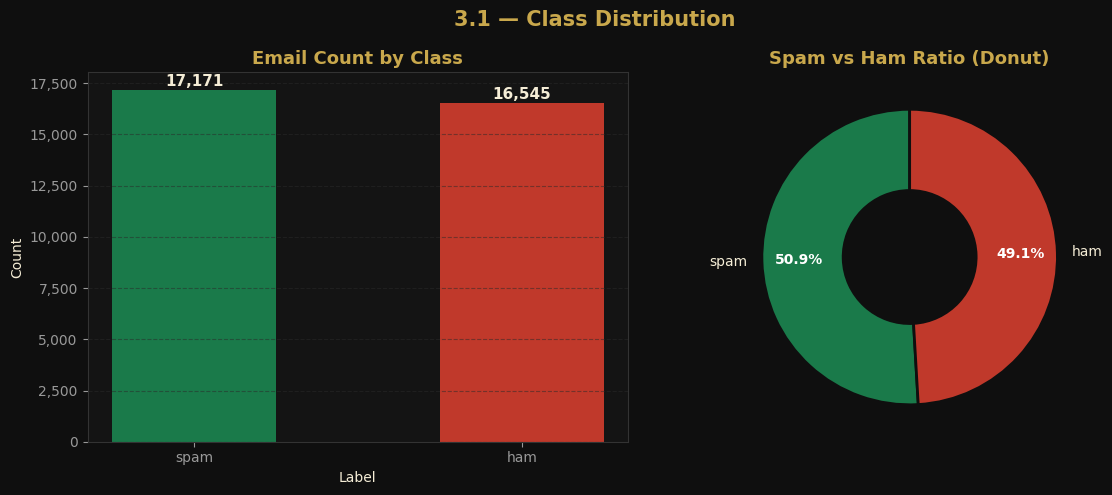

Ham  : 16,545 (49.1%)
Spam : 17,171 (50.9%)


In [18]:
# ── 3.1 Class Distribution ────────────────────────────────────────────────────
counts = df['label'].value_counts()
pcts   = df['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.1 — Class Distribution', color=GOLD)

bars = axes[0].bar(counts.index, counts.values, color=[GREEN, RED], edgecolor='none', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', va='bottom', color=CREAM, fontsize=11, fontweight='bold')
axes[0].set_title('Email Count by Class')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].grid(axis='y')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90,
    colors=[GREEN, RED], wedgeprops=dict(width=0.55, edgecolor='#0F0F0F', linewidth=2), pctdistance=0.75
)
for t in texts:  t.set_color(CREAM)
for a in autotexts: a.set_color('white'); a.set_fontweight('bold')
axes[1].set_title('Spam vs Ham Ratio (Donut)')

plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ham  : {counts["ham"]:,} ({pcts["ham"]:.1f}%)')
print(f'Spam : {counts["spam"]:,} ({pcts["spam"]:.1f}%)')

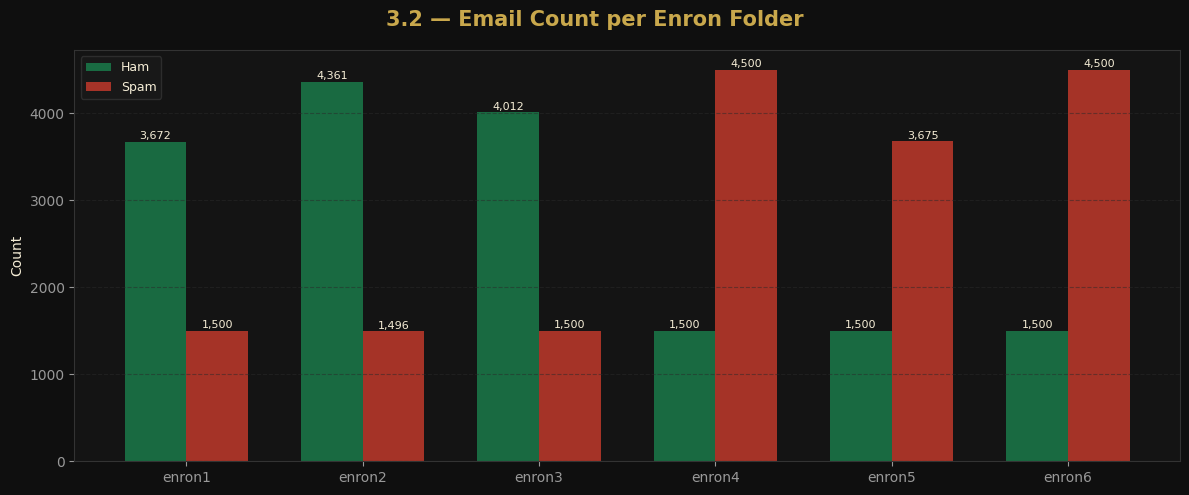

In [19]:
# ── 3.2 Emails per Enron Folder ───────────────────────────────────────────────
folder_counts = df.groupby(['source','label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('3.2 — Email Count per Enron Folder', color=GOLD)

x = np.arange(len(folder_counts)); w = 0.35
b1 = ax.bar(x-w/2, folder_counts['ham'],  width=w, label='Ham',  color=GREEN, alpha=0.85, edgecolor='none')
b2 = ax.bar(x+w/2, folder_counts['spam'], width=w, label='Spam', color=RED,   alpha=0.85, edgecolor='none')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8, color=CREAM)
ax.set_xticks(x); ax.set_xticklabels(folder_counts.index)
ax.set_ylabel('Count'); ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/02_emails_per_folder.png', dpi=150, bbox_inches='tight')
plt.show()

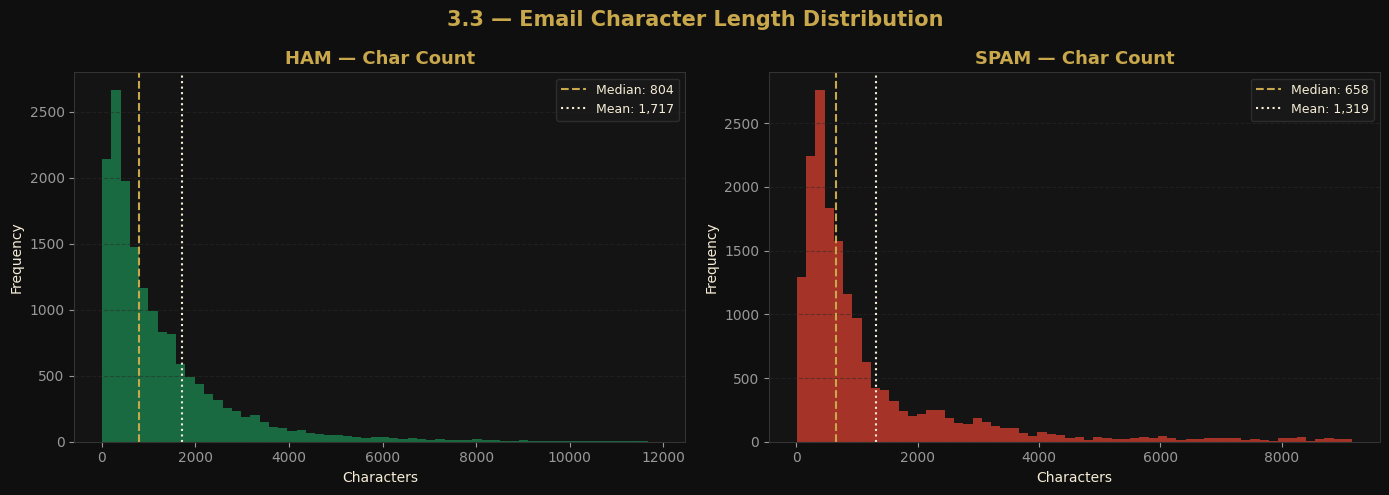

In [20]:
# ── 3.3 Email Length Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.3 — Email Character Length Distribution', color=GOLD)

for label, color, idx in [('ham', GREEN, 0), ('spam', RED, 1)]:
    data = df[df['label']==label]['char_count']
    clip = data.quantile(0.99)
    axes[idx].hist(data[data<=clip], bins=60, color=color, alpha=0.85, edgecolor='none')
    axes[idx].axvline(data.median(), color=GOLD,  linestyle='--', linewidth=1.5, label=f'Median: {data.median():,.0f}')
    axes[idx].axvline(data.mean(),   color=CREAM, linestyle=':',  linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    axes[idx].set_title(f'{label.upper()} — Char Count')
    axes[idx].set_xlabel('Characters'); axes[idx].set_ylabel('Frequency')
    axes[idx].legend(); axes[idx].grid(axis='y')

plt.tight_layout()
plt.savefig('outputs/03_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

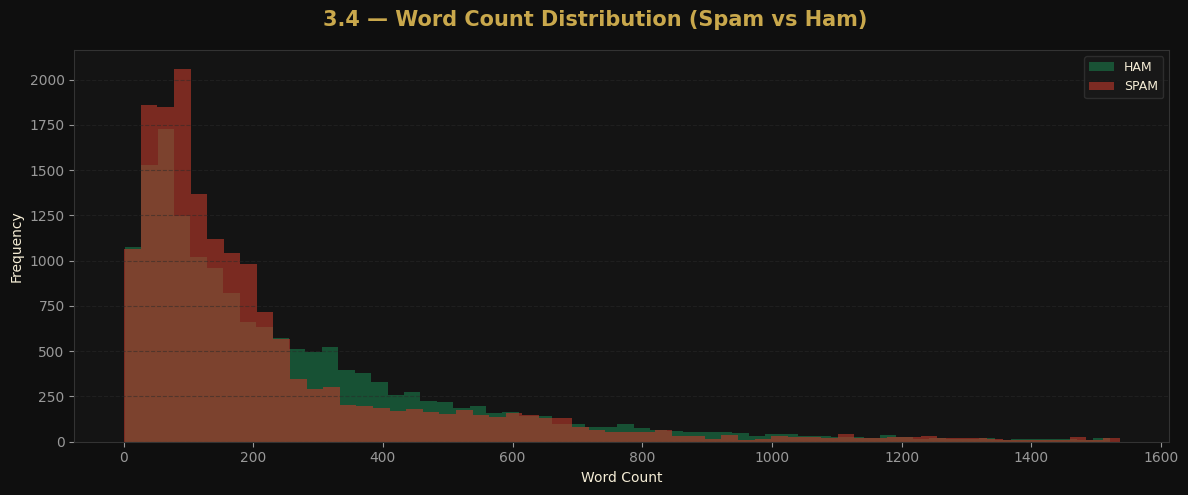

In [21]:
# ── 3.4 Word Count Distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('3.4 — Word Count Distribution (Spam vs Ham)', color=GOLD)
for label, color in [('ham', GREEN), ('spam', RED)]:
    data = df[df['label']==label]['word_count']
    clip = data.quantile(0.98)
    ax.hist(data[data<=clip], bins=60, color=color, alpha=0.6, label=label.upper(), edgecolor='none')
ax.set_xlabel('Word Count'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/04_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

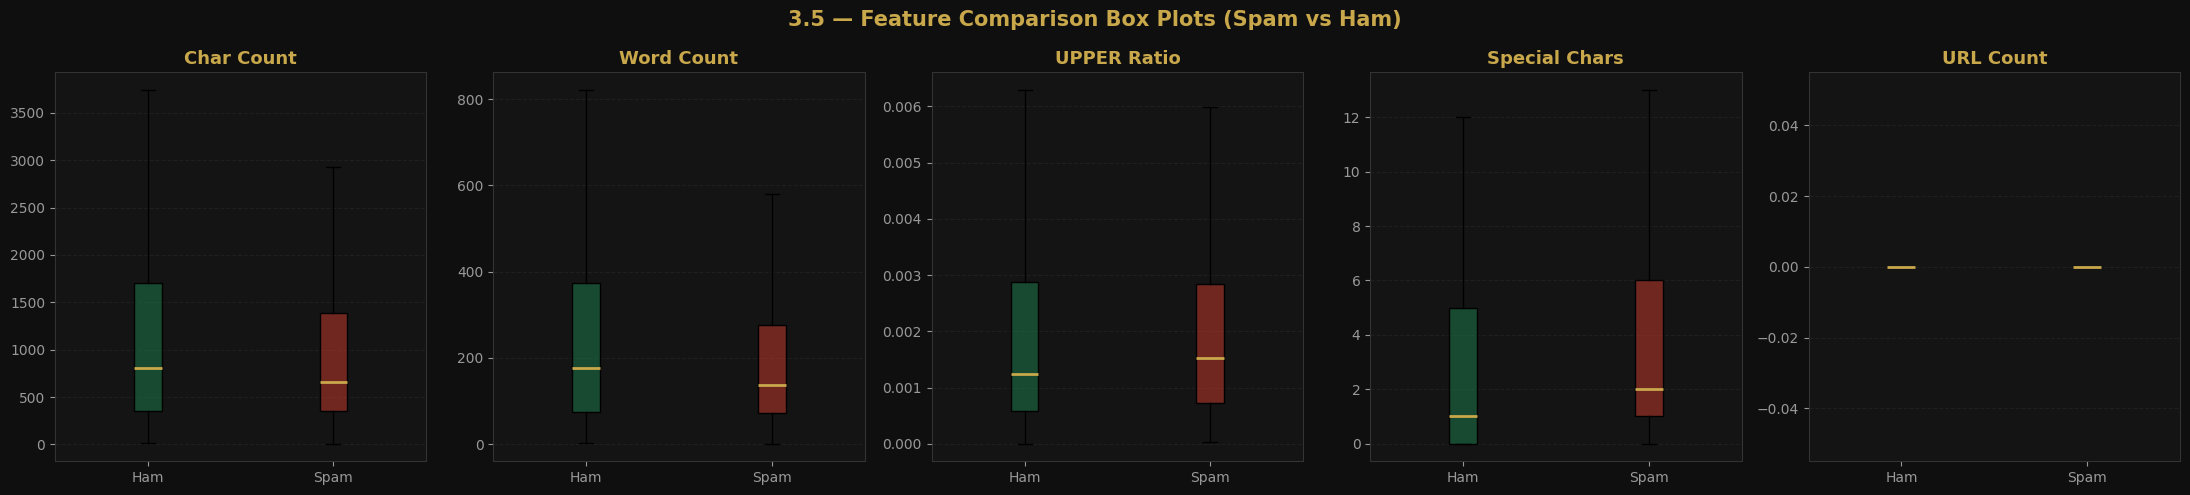

In [22]:
# ── 3.5 Feature Box Plots ─────────────────────────────────────────────────────
features = ['char_count','word_count','upper_ratio','special_count','url_count']
titles   = ['Char Count','Word Count','UPPER Ratio','Special Chars','URL Count']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('3.5 — Feature Comparison Box Plots (Spam vs Ham)', color=GOLD)

for ax, feat, title in zip(axes, features, titles):
    bp = ax.boxplot(
        [df[df['label']=='ham'][feat], df[df['label']=='spam'][feat]],
        labels=['Ham','Spam'], patch_artist=True, showfliers=False,
        medianprops=dict(color=GOLD, linewidth=2)
    )
    bp['boxes'][0].set_facecolor(f'{GREEN}88')
    bp['boxes'][1].set_facecolor(f'{RED}88')
    ax.set_title(title); ax.grid(axis='y')

plt.tight_layout()
plt.savefig('outputs/05_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

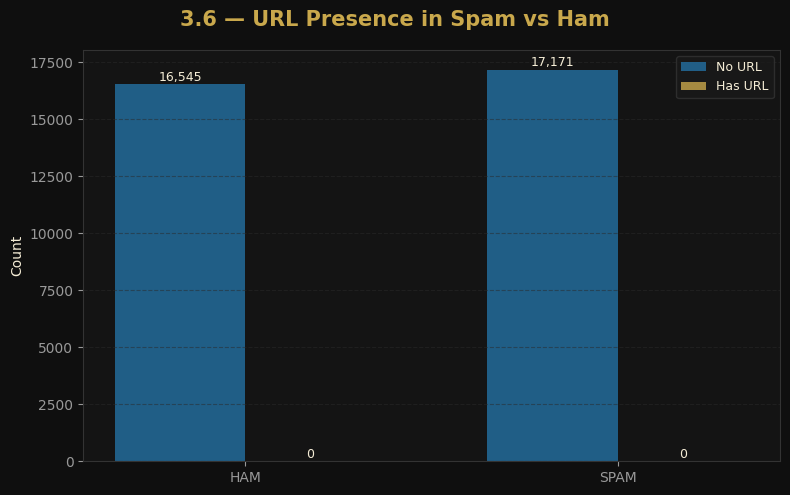

In [23]:
# ── 3.6 URL Presence ─────────────────────────────────────────────────────────
url_stats = df.groupby(['label','has_url']).size().unstack(fill_value=0)

# Ensure both columns exist even if no URLs are found in the dataset
if 0 not in url_stats.columns: url_stats[0] = 0
if 1 not in url_stats.columns: url_stats[1] = 0
url_stats = url_stats[[0, 1]]
url_stats.columns = ['No URL', 'Has URL']

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('3.6 — URL Presence in Spam vs Ham', color=GOLD)
x = np.arange(len(url_stats)); w = 0.35
b1 = ax.bar(x-w/2, url_stats['No URL'],  width=w, label='No URL',  color=f'{BLUE}CC',  edgecolor='none')
b2 = ax.bar(x+w/2, url_stats['Has URL'], width=w, label='Has URL', color=f'{GOLD}CC', edgecolor='none')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color=CREAM)
ax.set_xticks(x); ax.set_xticklabels(url_stats.index.str.upper())
ax.set_ylabel('Count'); ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/06_url_presence.png', dpi=150, bbox_inches='tight')
plt.show()

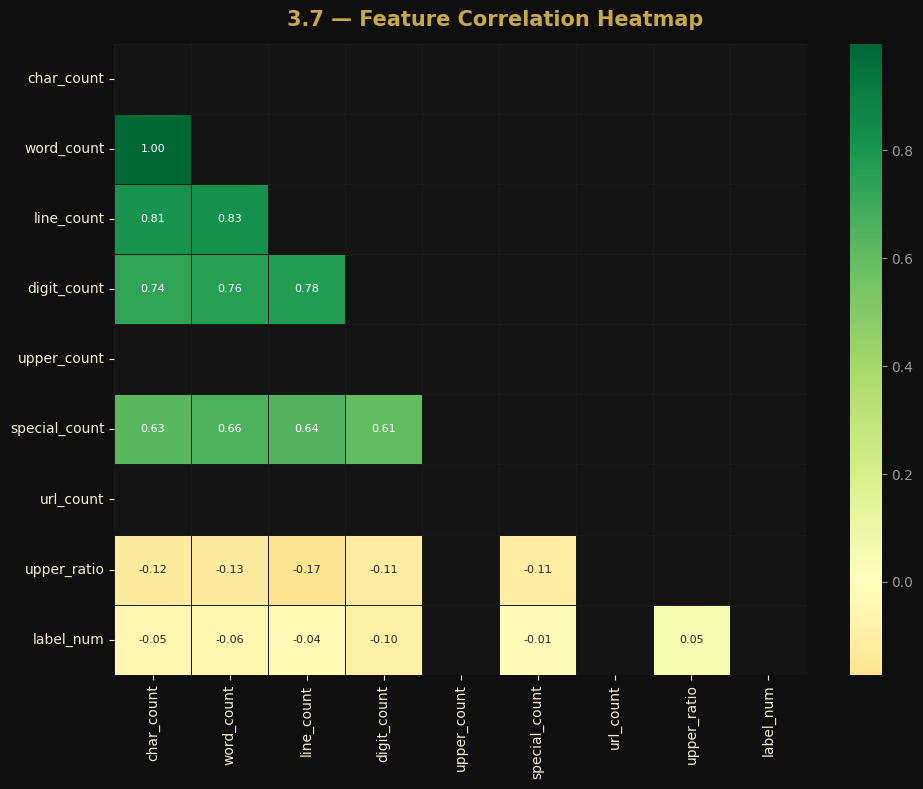

In [24]:
# ── 3.7 Correlation Heatmap ───────────────────────────────────────────────────
numeric_cols = ['char_count','word_count','line_count','digit_count',
                'upper_count','special_count','url_count','upper_ratio','label_num']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('3.7 — Feature Correlation Heatmap', color=GOLD)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#1A1A1A', ax=ax, annot_kws={'size':8})
ax.tick_params(colors=CREAM)
plt.tight_layout()
plt.savefig('outputs/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Text Analysis

In [25]:
# ── Clean text — identical to backend/main.py ─────────────────────────────────
HEADER_RE = re.compile(
    r'^(From|To|Cc|Bcc|Subject|Date|Message-ID|Mime-Version|'
    r'Content-Type|Content-Transfer-Encoding|X-[\w-]+):.*$',
    flags=re.IGNORECASE | re.MULTILINE,
)

def clean_text(text: str) -> str:
    if not isinstance(text, str): return ''
    text = HEADER_RE.sub('', text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Cleaning emails...')
df['clean'] = df['email'].apply(clean_text)
print(f'Done. Sample:')
print(df[df['label']=='spam']['clean'].iloc[0][:300])

Cleaning emails...
Done. Sample:
introducing doctor formulated hgh human growth hormone also called hgh is referred to in medical science as the master hormone it is very plentiful when we are young but near the age of twenty one our bodies begin to produce less of it by the time we are forty nearly everyone is deficient in hgh and


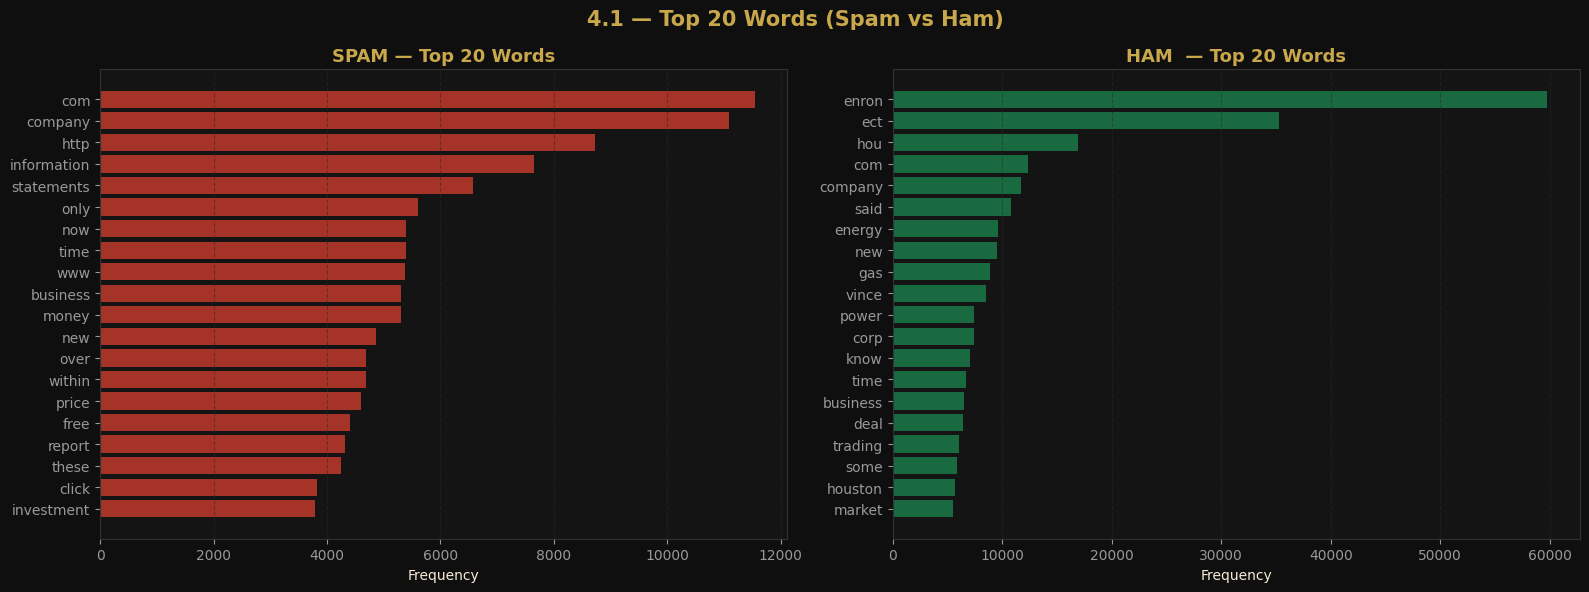

In [26]:
# ── 4.1 Top 20 Words ─────────────────────────────────────────────────────────
ENGLISH_STOP = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','have','has','had','do','does',
    'did','will','would','could','should','may','might','not','no',
    'this','that','it','its','i','we','you','he','she','they','my',
    'our','your','his','her','their','from','by','as','if','so',
    'about','up','out','all','any','just','than','then','when','there',
    'what','which','who','how','can','get','one','more','also','here',
    'am','im','re','us','me','him','them','dont','email','mail','message',
    'please','thank','thanks','subject','dear',
])

def top_words(label, n=20):
    corpus = ' '.join(df[df['label']==label]['clean'].values)
    words  = [w for w in corpus.split() if w not in ENGLISH_STOP and len(w) > 2]
    return Counter(words).most_common(n)

spam_words = top_words('spam')
ham_words  = top_words('ham')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4.1 — Top 20 Words (Spam vs Ham)', color=GOLD)

for ax, words, color, title in [
    (axes[0], spam_words, RED,   'SPAM — Top 20 Words'),
    (axes[1], ham_words,  GREEN, 'HAM  — Top 20 Words'),
]:
    lw = [w for w,_ in words]; cw = [c for _,c in words]
    ax.barh(lw[::-1], cw[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_title(title); ax.set_xlabel('Frequency'); ax.grid(axis='x')

plt.tight_layout()
plt.savefig('outputs/08_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

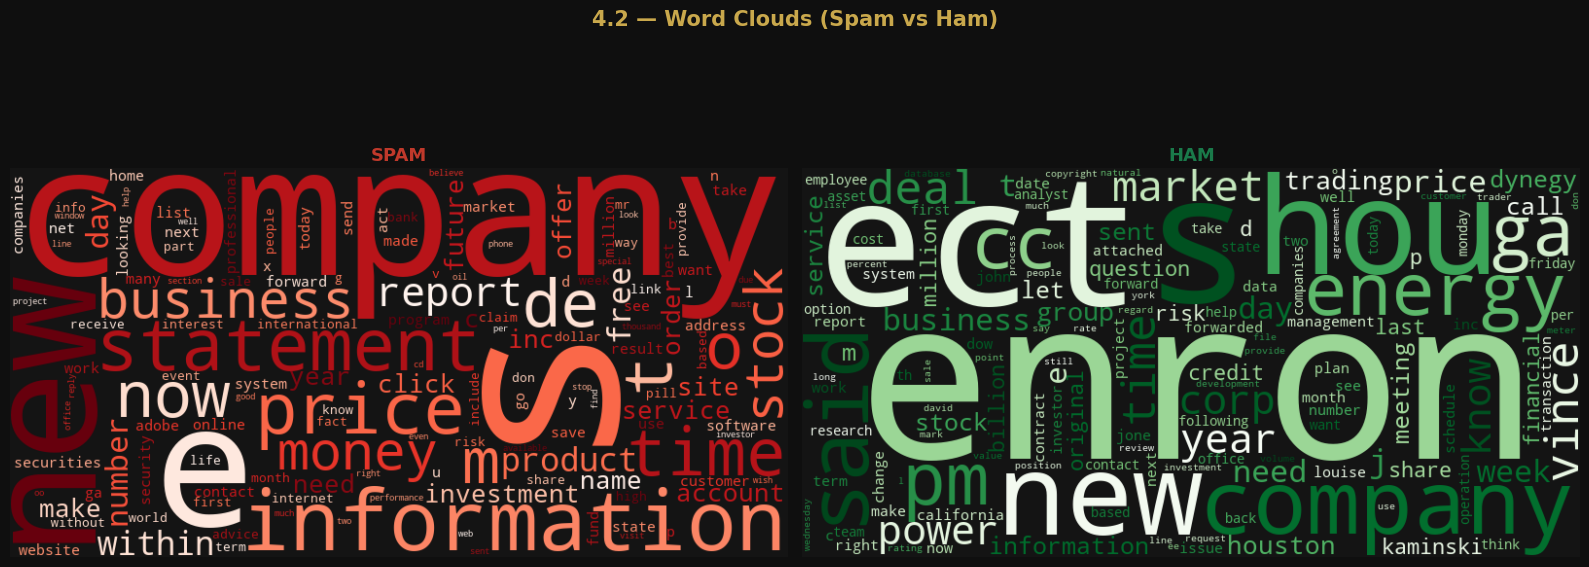

In [27]:
# ── 4.2 Word Clouds ───────────────────────────────────────────────────────────
spam_corpus = ' '.join(df[df['label']=='spam']['clean'].values)
ham_corpus  = ' '.join(df[df['label']=='ham']['clean'].values)
wc_cfg = dict(max_words=150, stopwords=STOPWORDS|ENGLISH_STOP,
              collocations=False, background_color='#141414',
              prefer_horizontal=0.85, width=800, height=400)

wc_spam = WordCloud(colormap='Reds',   **wc_cfg).generate(spam_corpus)
wc_ham  = WordCloud(colormap='Greens', **wc_cfg).generate(ham_corpus)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('4.2 — Word Clouds (Spam vs Ham)', color=GOLD)
axes[0].imshow(wc_spam, interpolation='bilinear'); axes[0].set_title('SPAM', color=RED);  axes[0].axis('off')
axes[1].imshow(wc_ham,  interpolation='bilinear'); axes[1].set_title('HAM',  color=GREEN); axes[1].axis('off')
plt.tight_layout()
plt.savefig('outputs/09_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

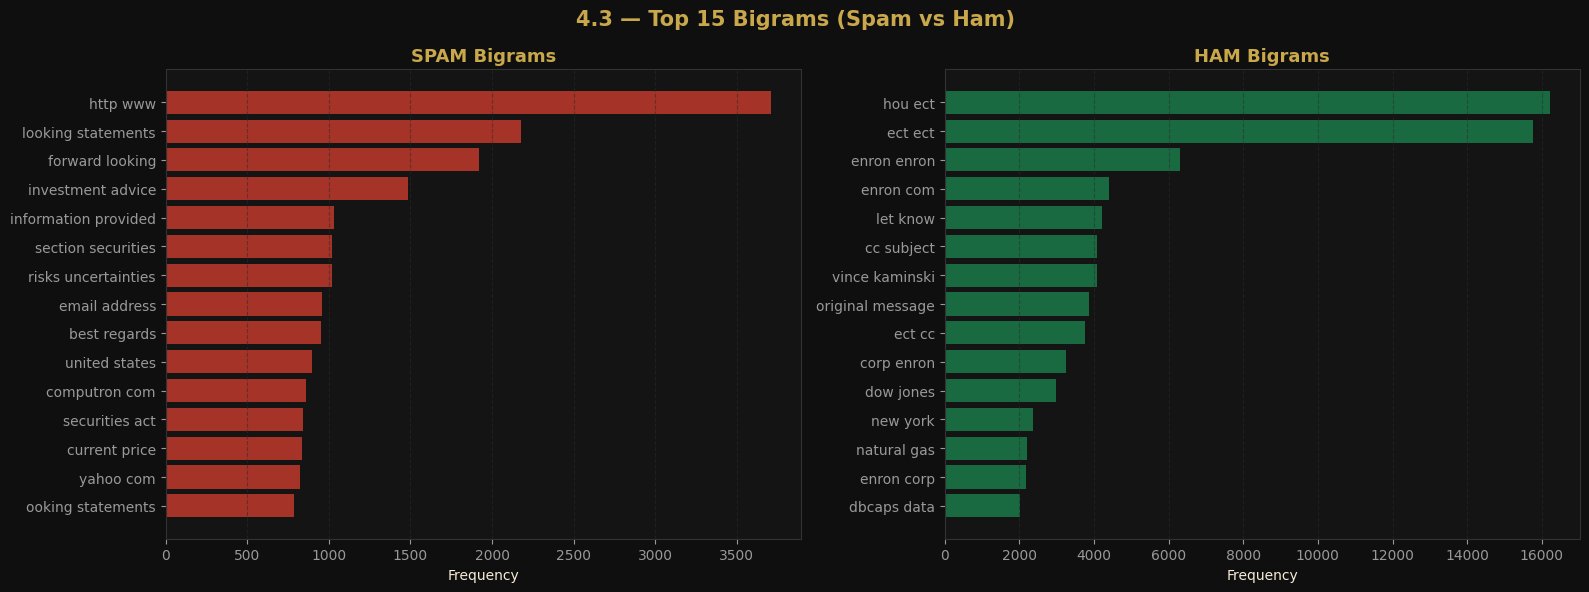

In [28]:
# ── 4.3 Bigrams ───────────────────────────────────────────────────────────────
def top_ngrams(label, n=2, top_k=15):
    corpus = df[df['label']==label]['clean'].values
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english', max_features=10000)
    X   = vec.fit_transform(corpus)
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).tolist()[0])
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4.3 — Top 15 Bigrams (Spam vs Ham)', color=GOLD)
for ax, ng, color, title in [(axes[0],top_ngrams('spam',2),RED,'SPAM Bigrams'),(axes[1],top_ngrams('ham',2),GREEN,'HAM Bigrams')]:
    ln=[g for g,_ in ng]; cn=[c for _,c in ng]
    ax.barh(ln[::-1], cn[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_title(title); ax.set_xlabel('Frequency'); ax.grid(axis='x')
plt.tight_layout()
plt.savefig('outputs/10_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

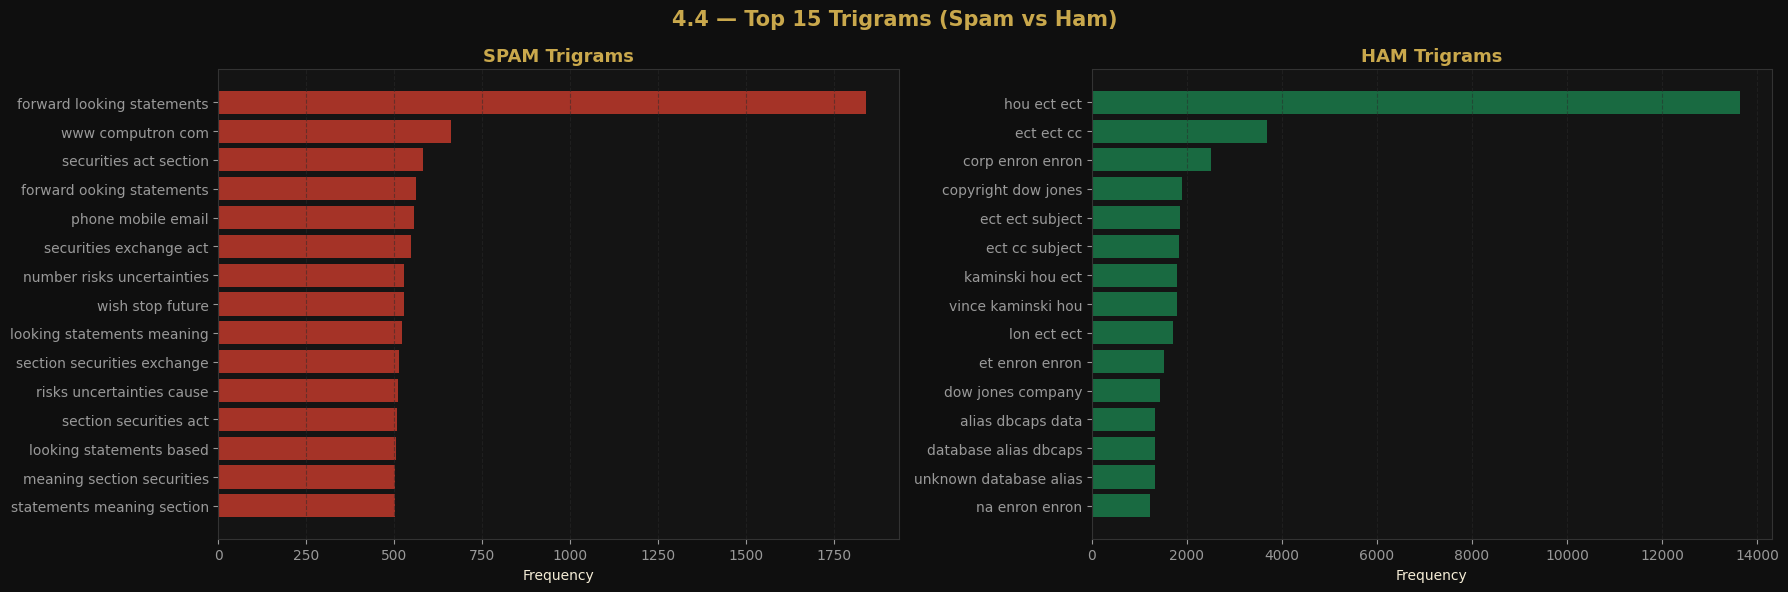

In [29]:
# ── 4.4 Trigrams ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('4.4 — Top 15 Trigrams (Spam vs Ham)', color=GOLD)
for ax, ng, color, title in [(axes[0],top_ngrams('spam',3),RED,'SPAM Trigrams'),(axes[1],top_ngrams('ham',3),GREEN,'HAM Trigrams')]:
    ln=[g for g,_ in ng]; cn=[c for _,c in ng]
    ax.barh(ln[::-1], cn[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_title(title); ax.set_xlabel('Frequency'); ax.grid(axis='x')
plt.tight_layout()
plt.savefig('outputs/11_trigrams.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Preprocessing Pipeline

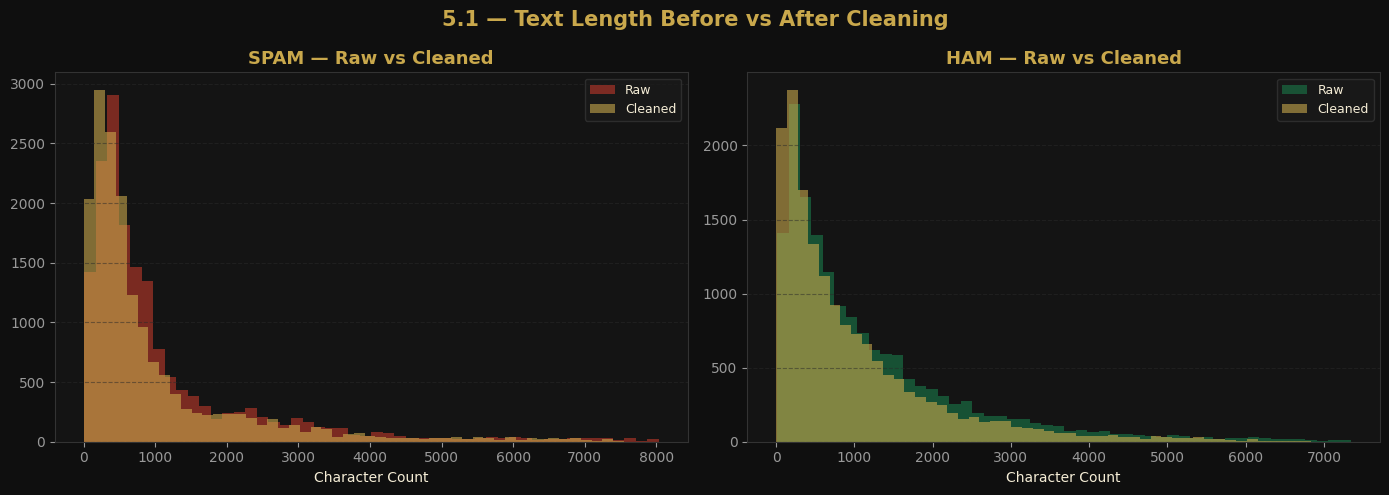

Average reduction %:
       mean  median
label              
ham    24.5    20.4
spam   22.7    18.5


In [30]:
# ── 5.1 Before vs After Cleaning ─────────────────────────────────────────────
df['clean_char_count'] = df['clean'].str.len()
df['reduction_pct']    = (1 - df['clean_char_count'] / (df['char_count']+1)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5.1 — Text Length Before vs After Cleaning', color=GOLD)
for label, color, idx in [('spam', RED, 0), ('ham', GREEN, 1)]:
    sub  = df[df['label']==label]; clip = sub['char_count'].quantile(0.98)
    axes[idx].hist(sub[sub['char_count']<=clip]['char_count'],       bins=50, alpha=0.6, color=color, label='Raw',     edgecolor='none')
    axes[idx].hist(sub[sub['char_count']<=clip]['clean_char_count'], bins=50, alpha=0.6, color=GOLD,  label='Cleaned', edgecolor='none')
    axes[idx].set_title(f'{label.upper()} — Raw vs Cleaned')
    axes[idx].set_xlabel('Character Count'); axes[idx].legend(); axes[idx].grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/12_preprocessing_length_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Average reduction %:')
print(df.groupby('label')['reduction_pct'].agg(['mean','median']).round(1))

Train : 26,972   Test : 6,744


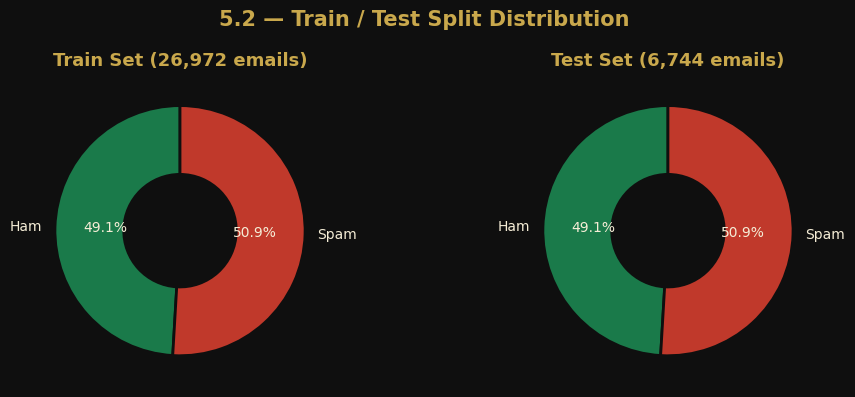

In [31]:
# ── 5.2 Train / Test Split ────────────────────────────────────────────────────
X = df['clean'].values
y = df['label_num'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train : {len(X_train):,}   Test : {len(X_test):,}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('5.2 — Train / Test Split Distribution', color=GOLD)
for ax, y_s, title in [(axes[0],y_train,'Train Set'),(axes[1],y_test,'Test Set')]:
    u, c = np.unique(y_s, return_counts=True)
    ax.pie(c, labels=['Ham' if v==0 else 'Spam' for v in u], autopct='%1.1f%%',
           startangle=90, colors=[GREEN,RED], wedgeprops=dict(width=0.55, edgecolor='#0F0F0F', linewidth=2))
    ax.set_title(f'{title} ({len(y_s):,} emails)')
plt.tight_layout()
plt.savefig('outputs/13_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. TF-IDF Feature Analysis

In [32]:
# ── Fit TF-IDF — exact config as backend/main.py ──────────────────────────────
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.90, min_df=2, ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)
print(f'Vocabulary  : {len(vectorizer.vocabulary_):,}')
print(f'Train shape : {X_train_vec.shape}')
print(f'Test shape  : {X_test_vec.shape}')
print(f'Sparsity    : {(1 - X_train_vec.nnz/(X_train_vec.shape[0]*X_train_vec.shape[1])):.4%}')

Vocabulary  : 479,957
Train shape : (26972, 479957)
Test shape  : (6744, 479957)
Sparsity    : 99.9679%


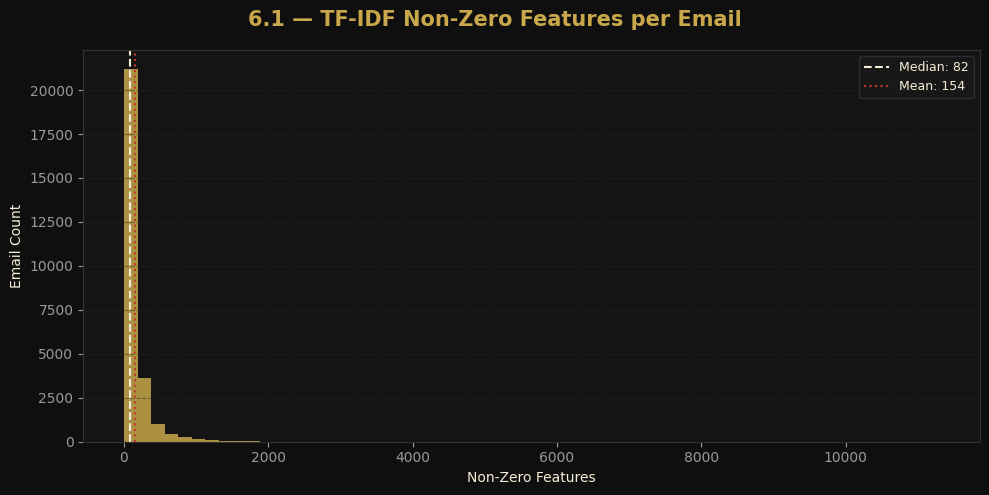

In [33]:
# ── 6.1 Non-Zero Features per Email ───────────────────────────────────────────
feat_per_email = np.diff(X_train_vec.indptr)
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('6.1 — TF-IDF Non-Zero Features per Email', color=GOLD)
ax.hist(feat_per_email, bins=60, color=GOLD, alpha=0.85, edgecolor='none')
ax.axvline(np.median(feat_per_email), color=CREAM, linestyle='--', linewidth=1.5, label=f'Median: {np.median(feat_per_email):.0f}')
ax.axvline(np.mean(feat_per_email),   color=RED,   linestyle=':',  linewidth=1.5, label=f'Mean: {np.mean(feat_per_email):.0f}')
ax.set_xlabel('Non-Zero Features'); ax.set_ylabel('Email Count'); ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/14_tfidf_features_per_email.png', dpi=150, bbox_inches='tight')
plt.show()

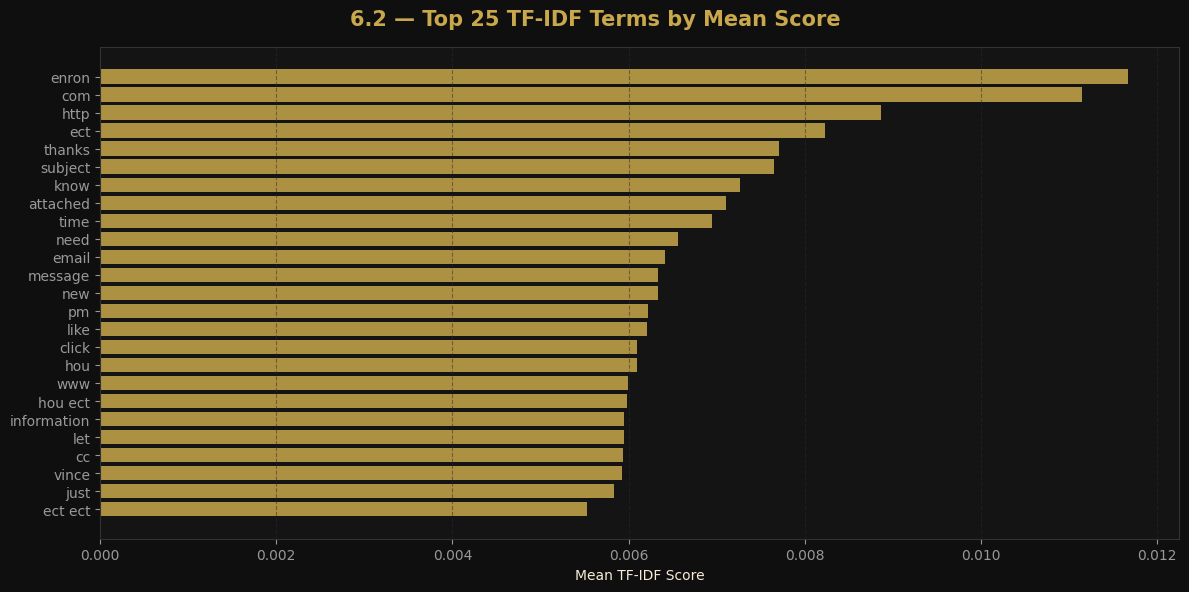

In [34]:
# ── 6.2 Top 25 TF-IDF Terms ───────────────────────────────────────────────────
feat_names  = vectorizer.get_feature_names_out()
mean_tfidf  = np.array(X_train_vec.mean(axis=0)).flatten()
top_idx     = mean_tfidf.argsort()[::-1][:25]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('6.2 — Top 25 TF-IDF Terms by Mean Score', color=GOLD)
ax.barh(feat_names[top_idx][::-1], mean_tfidf[top_idx][::-1], color=GOLD, alpha=0.85, edgecolor='none')
ax.set_xlabel('Mean TF-IDF Score'); ax.grid(axis='x')
plt.tight_layout()
plt.savefig('outputs/15_tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model Training

In [35]:
# ── Multinomial Naive Bayes — exact config as backend/main.py ─────────────────
model  = MultinomialNB(alpha=0.1)
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]
acc    = accuracy_score(y_test, y_pred)
print(f'Test Accuracy : {acc*100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

Test Accuracy : 99.32%

              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99      3309
        Spam       0.99      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



Accuracy  : 99.07% ± 0.07%
F1        : 0.9909 ± 0.0006
Precision : 0.9891
Recall    : 0.9928


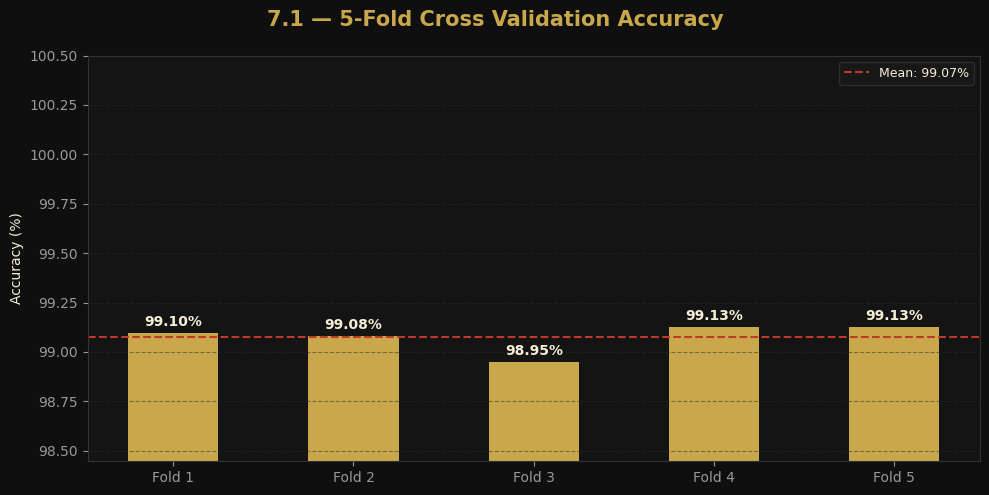

In [36]:
# ── 7.1 5-Fold Cross Validation ───────────────────────────────────────────────
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.90, min_df=2, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=0.1))
])
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy',  n_jobs=-1)
cv_f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1',        n_jobs=-1)
cv_pre = cross_val_score(pipe, X, y, cv=cv, scoring='precision', n_jobs=-1)
cv_rec = cross_val_score(pipe, X, y, cv=cv, scoring='recall',    n_jobs=-1)

print(f'Accuracy  : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'F1        : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'Precision : {cv_pre.mean():.4f}')
print(f'Recall    : {cv_rec.mean():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('7.1 — 5-Fold Cross Validation Accuracy', color=GOLD)
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_acc*100, color=GOLD, edgecolor='none', width=0.5)
for bar, val in zip(bars, cv_acc*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2f}%', ha='center', va='bottom', color=CREAM, fontsize=10, fontweight='bold')
ax.axhline(cv_acc.mean()*100, color=RED, linestyle='--', linewidth=1.5, label=f'Mean: {cv_acc.mean()*100:.2f}%')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim([cv_acc.min()*100-0.5, 100.5])
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/16_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Evaluation Metrics & Graphs

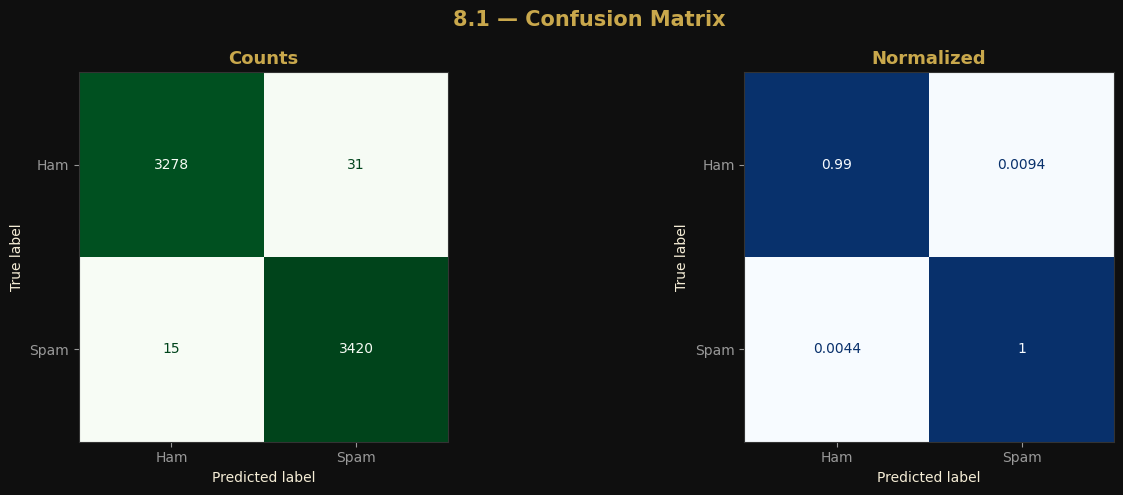

TN (Ham correct) : 3,278  |  FP (Ham flagged spam) : 31
FN (Spam missed) : 15  |  TP (Spam caught)      : 3,420


In [37]:
# ── 8.1 Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('8.1 — Confusion Matrix', color=GOLD)
ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam']).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Counts'); axes[0].set_facecolor('#141414')
cm_norm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=['Ham','Spam']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalized'); axes[1].set_facecolor('#141414')
plt.tight_layout()
plt.savefig('outputs/17_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
tn,fp,fn,tp = cm.ravel()
print(f'TN (Ham correct) : {tn:,}  |  FP (Ham flagged spam) : {fp:,}')
print(f'FN (Spam missed) : {fn:,}  |  TP (Spam caught)      : {tp:,}')

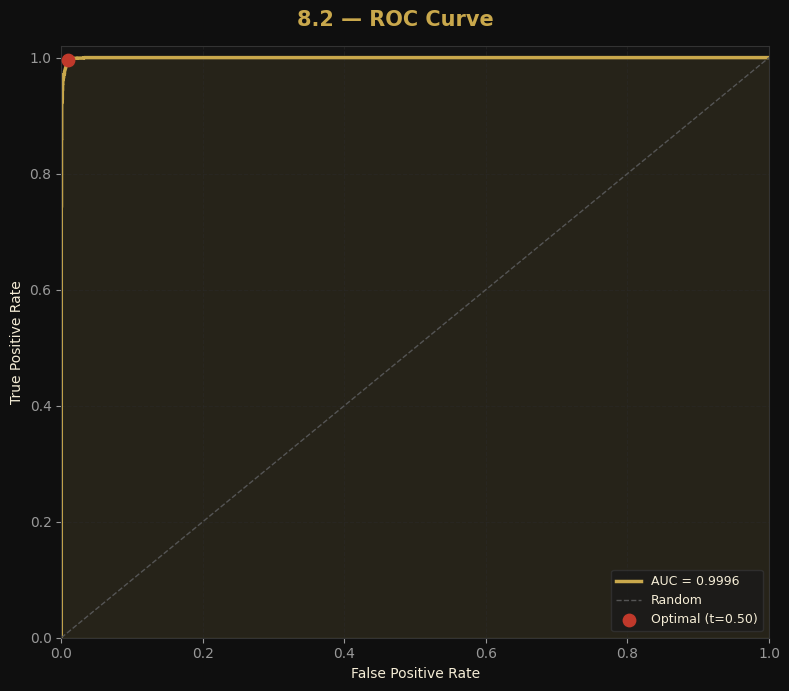

AUC : 0.9996


In [38]:
# ── 8.2 ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, thr_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle('8.2 — ROC Curve', color=GOLD)
ax.plot(fpr, tpr, color=GOLD, linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1], color='#555555', linestyle='--', linewidth=1, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color=GOLD)
opt = np.argmax(tpr-fpr)
ax.scatter(fpr[opt], tpr[opt], color=RED, s=80, zorder=5, label=f'Optimal (t={thr_roc[opt]:.2f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right'); ax.grid(True); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('outputs/18_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC : {roc_auc:.4f}')

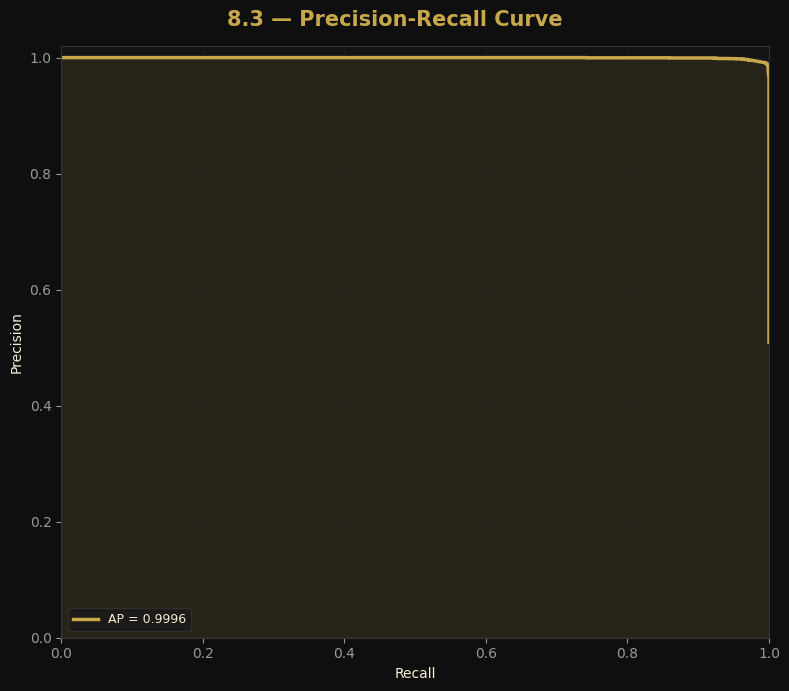

In [39]:
# ── 8.3 Precision-Recall Curve ───────────────────────────────────────────────
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle('8.3 — Precision-Recall Curve', color=GOLD)
ax.plot(rec_arr, prec_arr, color=GOLD, linewidth=2.5, label=f'AP = {avg_prec:.4f}')
ax.fill_between(rec_arr, prec_arr, alpha=0.1, color=GOLD)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(loc='lower left'); ax.grid(True); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('outputs/19_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

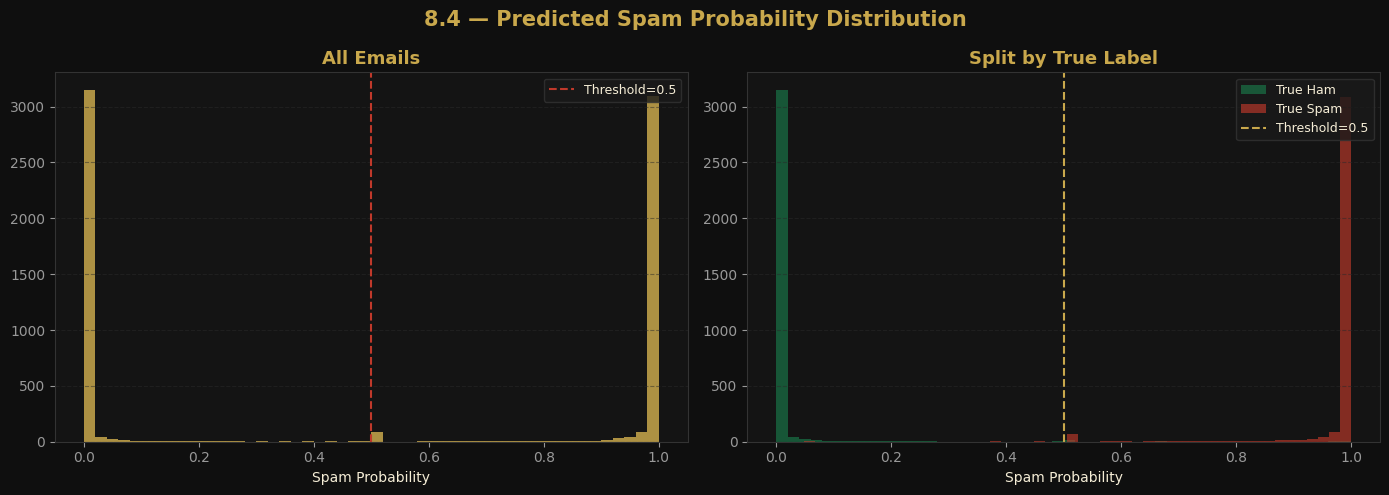

In [40]:
# ── 8.4 Probability Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('8.4 — Predicted Spam Probability Distribution', color=GOLD)
axes[0].hist(y_prob, bins=50, color=GOLD, alpha=0.85, edgecolor='none')
axes[0].axvline(0.5, color=RED, linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[0].set_title('All Emails'); axes[0].set_xlabel('Spam Probability'); axes[0].legend(); axes[0].grid(axis='y')
axes[1].hist(y_prob[y_test==0], bins=50, alpha=0.65, color=GREEN, label='True Ham',  edgecolor='none')
axes[1].hist(y_prob[y_test==1], bins=50, alpha=0.65, color=RED,   label='True Spam', edgecolor='none')
axes[1].axvline(0.5, color=GOLD, linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[1].set_title('Split by True Label'); axes[1].set_xlabel('Spam Probability')
axes[1].legend(); axes[1].grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/20_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

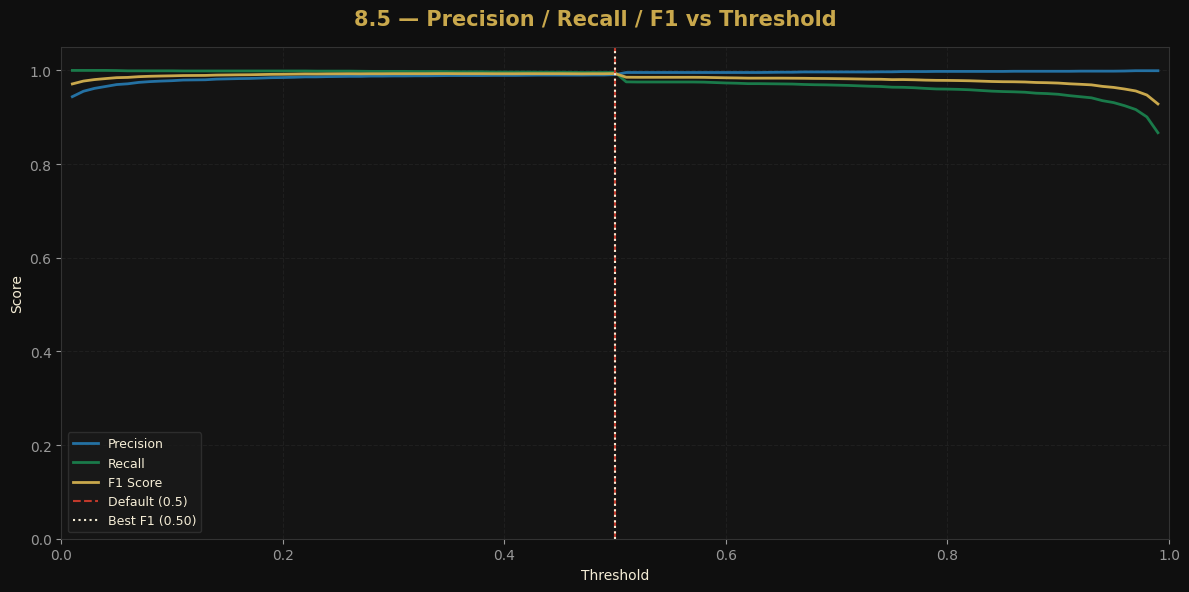

Best F1 threshold : 0.50  F1 = 0.9933


In [41]:
# ── 8.5 Threshold Analysis ────────────────────────────────────────────────────
thr_range = np.arange(0.01, 1.0, 0.01)
precs, recs, f1s = [], [], []
for t in thr_range:
    yp = (y_prob>=t).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=1))
    recs.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('8.5 — Precision / Recall / F1 vs Threshold', color=GOLD)
ax.plot(thr_range, precs, color=BLUE,  linewidth=2, label='Precision')
ax.plot(thr_range, recs,  color=GREEN, linewidth=2, label='Recall')
ax.plot(thr_range, f1s,   color=GOLD,  linewidth=2, label='F1 Score')
ax.axvline(0.5, color=RED, linestyle='--', linewidth=1.5, label='Default (0.5)')
best = np.argmax(f1s)
ax.axvline(thr_range[best], color=CREAM, linestyle=':', linewidth=1.5, label=f'Best F1 ({thr_range[best]:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score'); ax.legend(); ax.grid(True)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig('outputs/21_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best F1 threshold : {thr_range[best]:.2f}  F1 = {f1s[best]:.4f}')

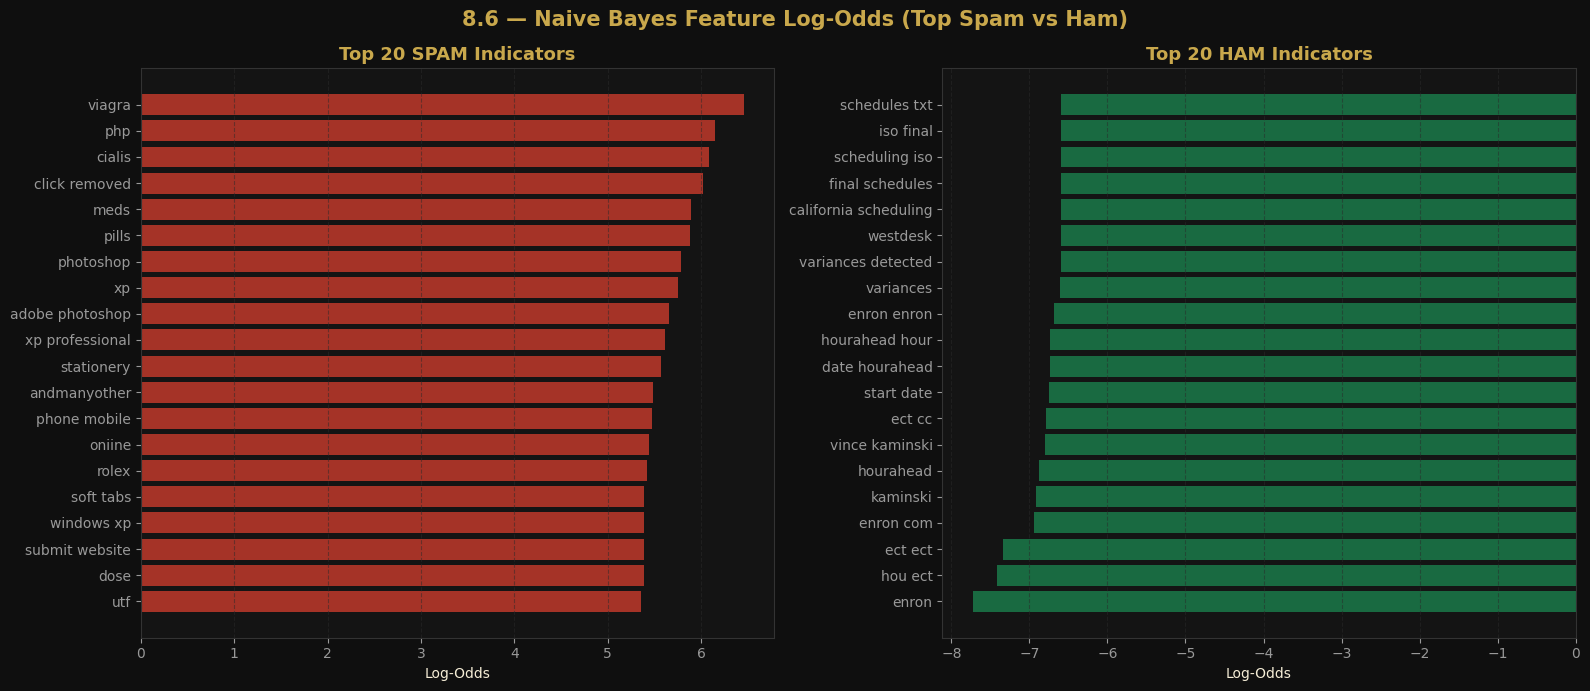

In [42]:
# ── 8.6 Naive Bayes Log-Odds Feature Weights ──────────────────────────────────
fn_arr   = np.array(vectorizer.get_feature_names_out())
log_odds = model.feature_log_prob_[1] - model.feature_log_prob_[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('8.6 — Naive Bayes Feature Log-Odds (Top Spam vs Ham)', color=GOLD)
axes[0].barh(fn_arr[log_odds.argsort()[::-1][:20]][::-1], log_odds[log_odds.argsort()[::-1][:20]][::-1], color=RED,   alpha=0.85, edgecolor='none')
axes[0].set_title('Top 20 SPAM Indicators'); axes[0].set_xlabel('Log-Odds'); axes[0].grid(axis='x')
axes[1].barh(fn_arr[log_odds.argsort()[:20]],             log_odds[log_odds.argsort()[:20]],             color=GREEN, alpha=0.85, edgecolor='none')
axes[1].set_title('Top 20 HAM Indicators');  axes[1].set_xlabel('Log-Odds'); axes[1].grid(axis='x')
plt.tight_layout()
plt.savefig('outputs/22_nb_feature_weights.png', dpi=150, bbox_inches='tight')
plt.show()

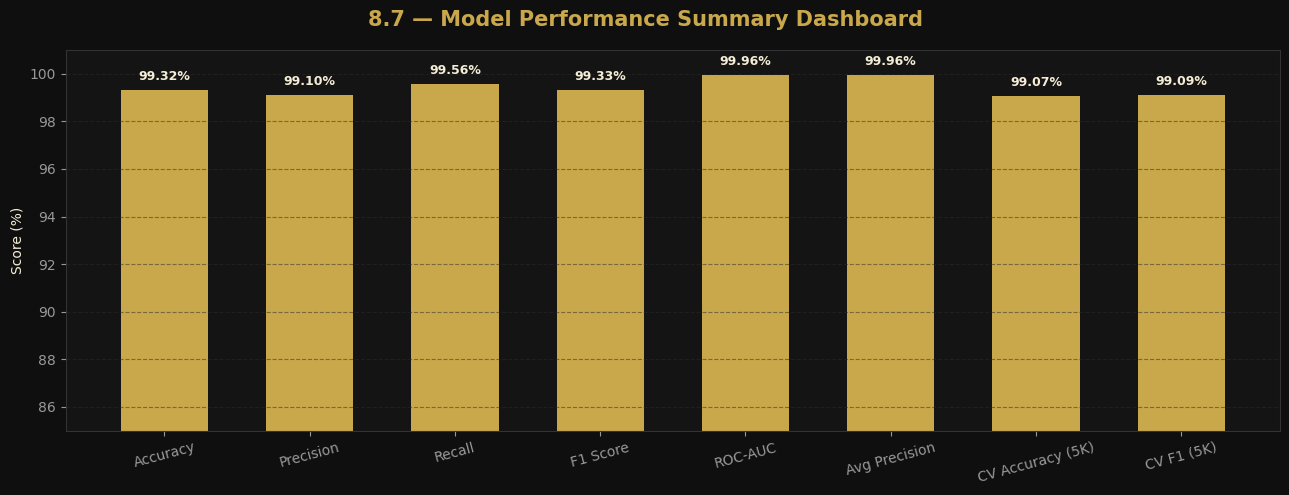


All Metrics:
  Accuracy              : 99.3179%
  Precision             : 99.1017%
  Recall                : 99.5633%
  F1 Score              : 99.3320%
  ROC-AUC               : 99.9599%
  Avg Precision         : 99.9552%
  CV Accuracy (5K)      : 99.0746%
  CV F1 (5K)            : 99.0932%


In [43]:
# ── 8.7 Metrics Summary Dashboard ────────────────────────────────────────────
metrics = {
    'Accuracy'        : accuracy_score(y_test, y_pred),
    'Precision'       : precision_score(y_test, y_pred),
    'Recall'          : recall_score(y_test, y_pred),
    'F1 Score'        : f1_score(y_test, y_pred),
    'ROC-AUC'         : roc_auc,
    'Avg Precision'   : avg_prec,
    'CV Accuracy (5K)': cv_acc.mean(),
    'CV F1 (5K)'      : cv_f1.mean(),
}
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('8.7 — Model Performance Summary Dashboard', color=GOLD)
names  = list(metrics.keys())
values = [v*100 for v in metrics.values()]
colors = [GOLD if v>=99 else GREEN if v>=95 else '#E67E22' for v in values]
bars   = ax.bar(names, values, color=colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=CREAM)
ax.set_ylabel('Score (%)'); ax.set_ylim([85,101])
ax.tick_params(axis='x', rotation=15); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('outputs/23_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll Metrics:')
for k,v in metrics.items(): print(f'  {k:<22}: {v*100:.4f}%')

---
## 9. LIME Explainability

Spam prob: 1.0000  |  hello welcome to health suite http www sere vi ra al xa x cod ag ci is na vi in and many other for very good pricess save yourself up to off all orders with us have a nice day


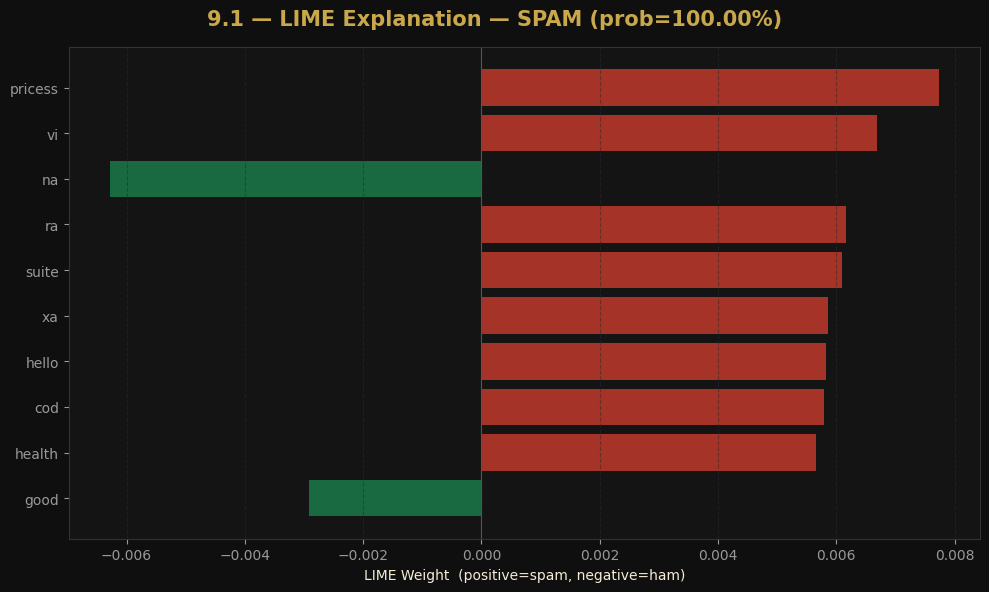

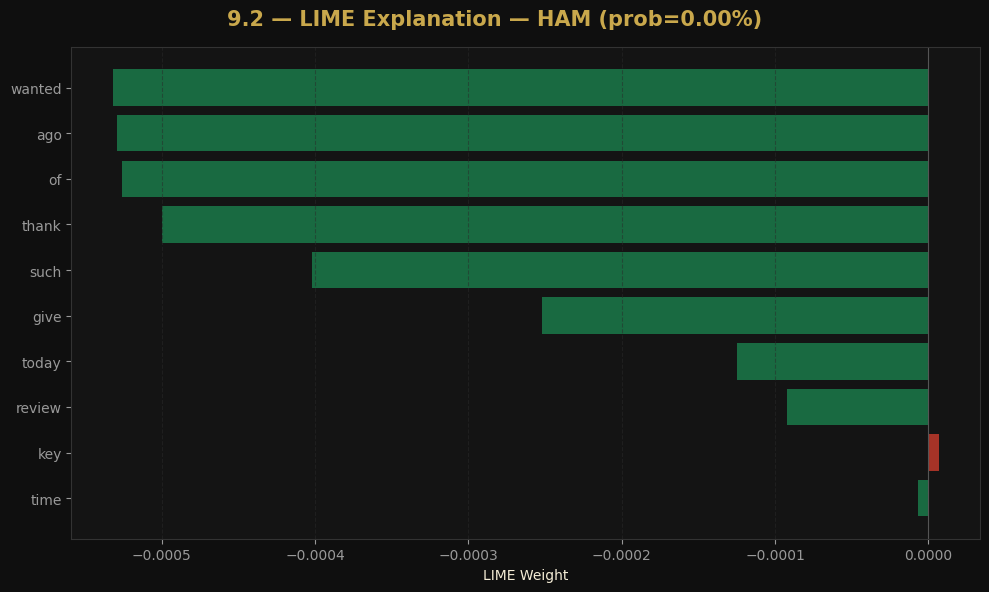

In [44]:
if not LIME_AVAILABLE:
    print('Run: pip install lime')
else:
    def predict_fn(texts):
        return model.predict_proba(vectorizer.transform([clean_text(t) for t in texts]))

    explainer = LimeTextExplainer(class_names=['Ham','Spam'])

    # Spam example
    spam_idx  = np.where((y_test==1)&(y_prob>0.95))[0]
    if len(spam_idx)==0: spam_idx = np.where(y_test==1)[0]
    s_text = X_test[spam_idx[0]]; s_prob = y_prob[spam_idx[0]]
    print(f'Spam prob: {s_prob:.4f}  |  {s_text[:200]}')

    exp = explainer.explain_instance(clean_text(s_text), predict_fn, num_features=10, num_samples=500, labels=(1,))
    lw = [w for w,_ in exp.as_list(label=1)]; ls = [s for _,s in exp.as_list(label=1)]

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'9.1 — LIME Explanation — SPAM (prob={s_prob:.2%})', color=GOLD)
    ax.barh(lw[::-1], ls[::-1], color=[RED if s>0 else GREEN for s in ls[::-1]], alpha=0.85, edgecolor='none')
    ax.axvline(0, color='#555555', linewidth=0.8)
    ax.set_xlabel('LIME Weight  (positive=spam, negative=ham)'); ax.grid(axis='x')
    plt.tight_layout()
    plt.savefig('outputs/24_lime_spam.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Ham example
    ham_idx = np.where((y_test==0)&(y_prob<0.05))[0]
    if len(ham_idx)==0: ham_idx = np.where(y_test==0)[0]
    h_text = X_test[ham_idx[0]]; h_prob = y_prob[ham_idx[0]]

    exp_h = explainer.explain_instance(clean_text(h_text), predict_fn, num_features=10, num_samples=500, labels=(1,))
    lw_h = [w for w,_ in exp_h.as_list(label=1)]; ls_h = [s for _,s in exp_h.as_list(label=1)]

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'9.2 — LIME Explanation — HAM (prob={h_prob:.2%})', color=GOLD)
    ax.barh(lw_h[::-1], ls_h[::-1], color=[RED if s>0 else GREEN for s in ls_h[::-1]], alpha=0.85, edgecolor='none')
    ax.axvline(0, color='#555555', linewidth=0.8)
    ax.set_xlabel('LIME Weight'); ax.grid(axis='x')
    plt.tight_layout()
    plt.savefig('outputs/25_lime_ham.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 10. Model Export

In [45]:
joblib.dump(model,      'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print('Saved: spam_model.pkl  and  vectorizer.pkl')
print()

# Verify
m2 = joblib.load('spam_model.pkl'); v2 = joblib.load('vectorizer.pkl')
test_cases = [
    'Congratulations! You WON $10,000. Click here to CLAIM your prize NOW!',
    'Hi team, please review the Q3 report before tomorrow meeting.',
    'URGENT: Your account suspended. Verify immediately.',
    'Can we reschedule the design review to 3pm Thursday?',
]
print('Verification:')
print('-'*70)
for t in test_cases:
    vec  = v2.transform([clean_text(t)])
    prob = m2.predict_proba(vec)[0][1]
    pred = 'SPAM' if prob>0.5 else 'HAM '
    print(f'[{pred}] {prob:.3f}  {t[:60]}')

Saved: spam_model.pkl  and  vectorizer.pkl

Verification:
----------------------------------------------------------------------
[SPAM] 0.994  Congratulations! You WON $10,000. Click here to CLAIM your p
[HAM ] 0.016  Hi team, please review the Q3 report before tomorrow meeting
[SPAM] 0.916  URGENT: Your account suspended. Verify immediately.
[HAM ] 0.015  Can we reschedule the design review to 3pm Thursday?
